In [9]:
# 1. 라이브러리 & 모델/데이터 로딩
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 3단계에서 저장한 모델 불러오기
with open('models/xgb_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

# 데이터 불러오기
X_test = pd.read_csv('data/processed/X_test.csv')
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()

class_names = {0: 'DoS', 1: 'Normal', 2: 'Probe', 3: 'R2L', 4: 'U2R'}

print("=== 모델 & 데이터 로딩 완료 ===")
print(f"X_test shape: {X_test.shape}")

=== 모델 & 데이터 로딩 완료 ===
X_test shape: (18896, 41)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_25148\2394174257.py:13: UserWarning: [20:09:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  xgb_model = pickle.load(f)


In [10]:
# 2. SHAP Explainer 생성
# Tree 기반 모델용 SHAP Explainer
explainer = shap.TreeExplainer(xgb_model)

# 계산 시간이 걸리므로 일부 샘플만 사용 (500개)
X_sample = X_test.sample(500, random_state=42)

shap_values = explainer.shap_values(X_sample)

print("=== SHAP 값 계산 완료 ===")
print(f"shap_values shape: {np.array(shap_values).shape}")

=== SHAP 값 계산 완료 ===
shap_values shape: (500, 41, 5)


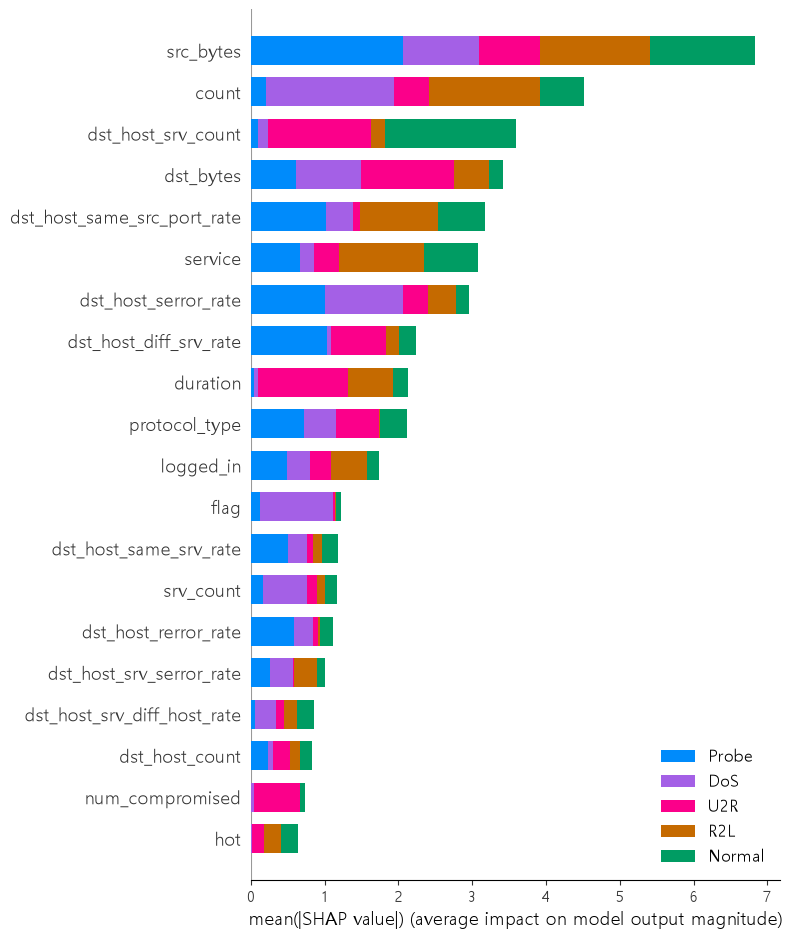

In [11]:
# 3. 전체 피처 중요도
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type='bar', 
                   class_names=list(class_names.values()),
                   show=False)
plt.tight_layout()
plt.show()

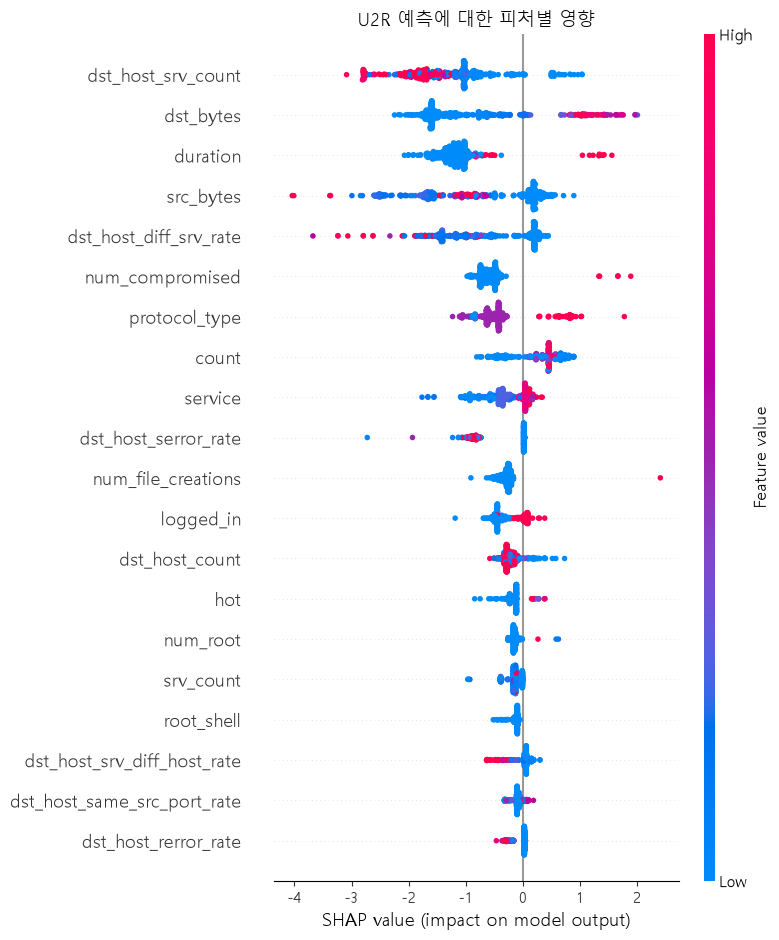

In [12]:
# 4. U2R 클래스에 대한 SHAP 값만 추출
shap_values_u2r = shap_values[4] if isinstance(shap_values, list) else shap_values[:,:,4]

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_u2r, X_sample, show=False)
plt.title('U2R 예측에 대한 피처별 영향', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# 5. 다중공선성 그룹 비교 (SYN 에러 계열 4개 피처의 중요도 비교)
syn_error_features = ['serror_rate', 'srv_serror_rate', 
                       'dst_host_serror_rate', 'dst_host_srv_serror_rate']

mean_shap = np.abs(shap_values).mean(axis=(0,2)) if len(np.array(shap_values).shape)==3 else np.abs(np.array(shap_values)).mean(axis=(0,1))

importance_df = pd.DataFrame({
    'feature': X_sample.columns,
    'importance': mean_shap
}).set_index('feature')

print("=== SYN 에러 계열 피처 중요도 ===")
print(importance_df.loc[syn_error_features].sort_values('importance', ascending=False))

=== SYN 에러 계열 피처 중요도 ===
                          importance
feature                             
dst_host_serror_rate        0.591049
dst_host_srv_serror_rate    0.201828
serror_rate                 0.089126
srv_serror_rate             0.050078
